## Pytorching the neural network

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [2]:
words = open('names.txt','r').read().splitlines()

# build the vocab of chars and mappings to/from integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [3]:
# build dataset
block_size = 3 # context length: how many chars do we take to predict the next one

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X, Y
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr , Ytr = build_dataset(words[:n1]) #80
Xdev, Ydev = build_dataset(words[n1:n2]) #10
Xte, Yte = build_dataset(words[n2:]) #10


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [4]:
# MLP revisited no more magic numbers

n_embd = 10 # the dimensionality of the char embedding vector
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(214738323) # reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd*block_size)**2 # gain / sqrt(fanin (input))
b1 = torch.randn(n_hidden,generator=g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),generator=g) * 0.01 # want logits small
b2 = torch.randn(vocab_size, generator=g) * 0 # want no bias

# dont need gradients for these values, automatically updated without

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

# note dont put W2 at zero 

12297


In [ ]:
# lets train a deeper network by mimicking pytorch

class Linear:

    def __init__(self,fan_in,fan_out,bias=True):
        self.weight = torch.randn((fan_in,fan_out),generator=g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self,dim, eps=1e-5,momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)


    def __call__(self,x):

        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the char embedding vector
n_hidden = 100 # the number of neurons in the hiddne layer of the MLP
g = torch.Generator().manual_seed(21474853647)

C = torch.randn((vocab_size, n_embd), generator = g)
layers = [ Linear(n_embd * block_size, n_hidden), Tanh(),
          Linear( n_hidden, n_hidden), Tanh(),
          Linear( n_hidden, n_hidden), Tanh(),
          Linear( n_hidden, n_hidden), Tanh(),
          Linear( n_hidden, n_hidden), Tanh(),
          Linear( n_hidden, vocab_size),]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

46497


In [17]:
# same optimization

max_steps = 20000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,),generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # emb the chars into vecs
    x = emb.view(emb.shape[0],-1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x,Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # After_debug would take out retain graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

   # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

      0/  20000: 2.2006
  10000/  20000: 2.1146


Lets visualize the look of this

layer 1 (      Tanh): mean +0.00, std 0.81, saturated: 32.25%
layer 3 (      Tanh): mean +0.02, std 0.82, saturated: 34.28%
layer 5 (      Tanh): mean +0.09, std 0.84, saturated: 36.06%
layer 7 (      Tanh): mean +0.06, std 0.86, saturated: 39.88%
layer 9 (      Tanh): mean -0.05, std 0.78, saturated: 20.94%


/tmp/ipykernel_1552621/1766753057.py:8: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

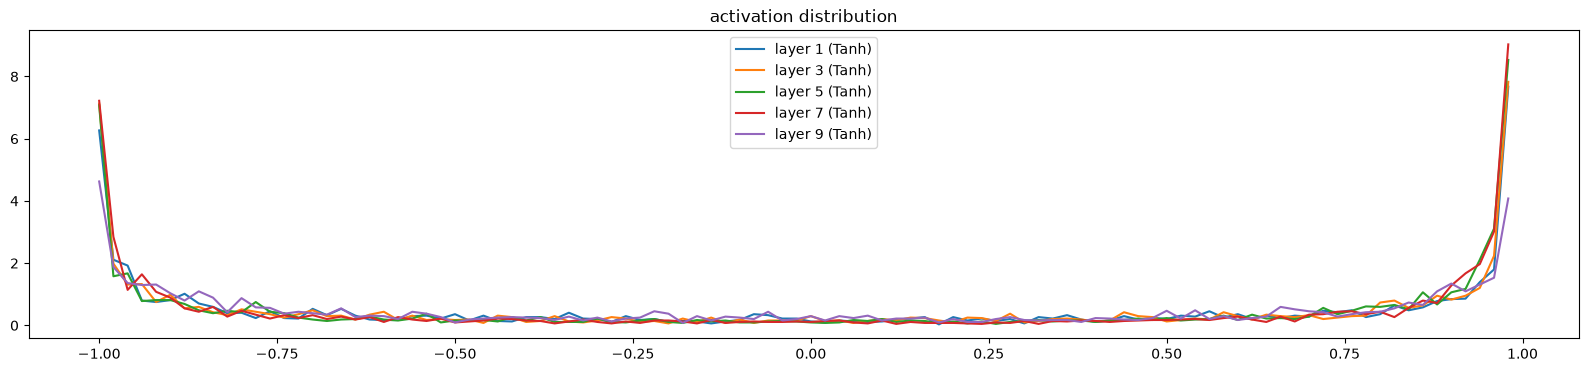

In [ ]:
# visualize histograms forward propogation/activation

plt.figure(figsize=(20,4)) # widh and heigh of the plt
legends = []
for i, layer in enumerate(layers[:-1]): # exlude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.000024, std 2.789939e-03
layer 3 (      Tanh): mean +0.000045, std 2.669587e-03
layer 5 (      Tanh): mean +0.000110, std 2.646398e-03
layer 7 (      Tanh): mean -0.000002, std 3.076705e-03
layer 9 (      Tanh): mean -0.000101, std 3.814217e-03


Text(0.5, 1.0, 'gradient distribution')

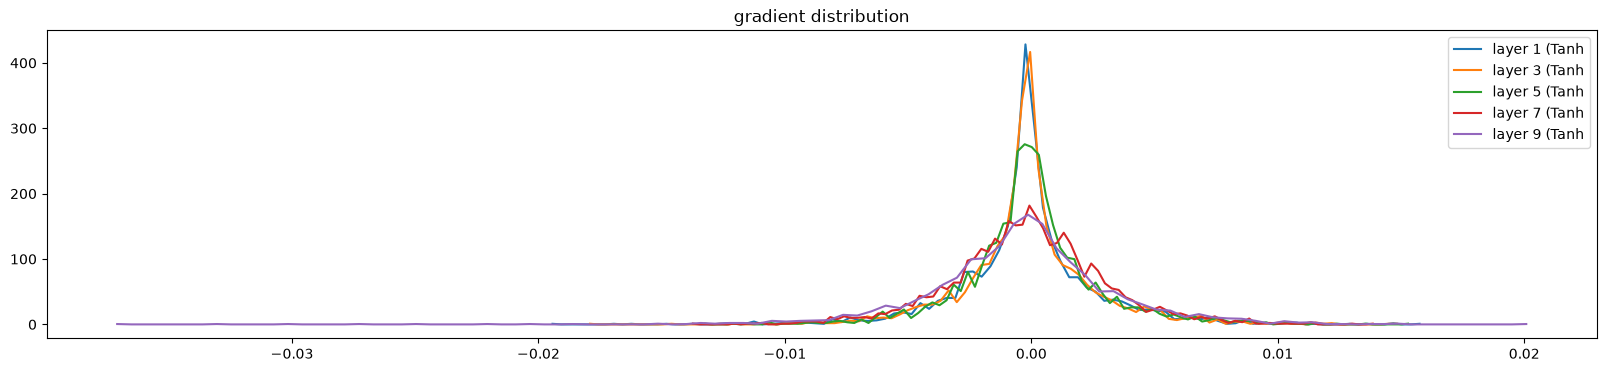

In [ ]:

# visualize histograms backward propogation
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000039 | std 1.038073e-02 | grad:data ratio 9.423481e-03
weight  (30, 100) | mean +0.000010 | std 8.985836e-03 | grad:data ratio 2.599510e-02
weight (100, 100) | mean +0.000051 | std 5.892014e-03 | grad:data ratio 2.926278e-02
weight (100, 100) | mean +0.000005 | std 5.905448e-03 | grad:data ratio 2.974822e-02
weight (100, 100) | mean -0.000032 | std 6.174209e-03 | grad:data ratio 3.121551e-02
weight (100, 100) | mean -0.000299 | std 7.483452e-03 | grad:data ratio 4.091942e-02
weight  (100, 27) | mean -0.000000 | std 2.523143e-02 | grad:data ratio 1.881259e-01


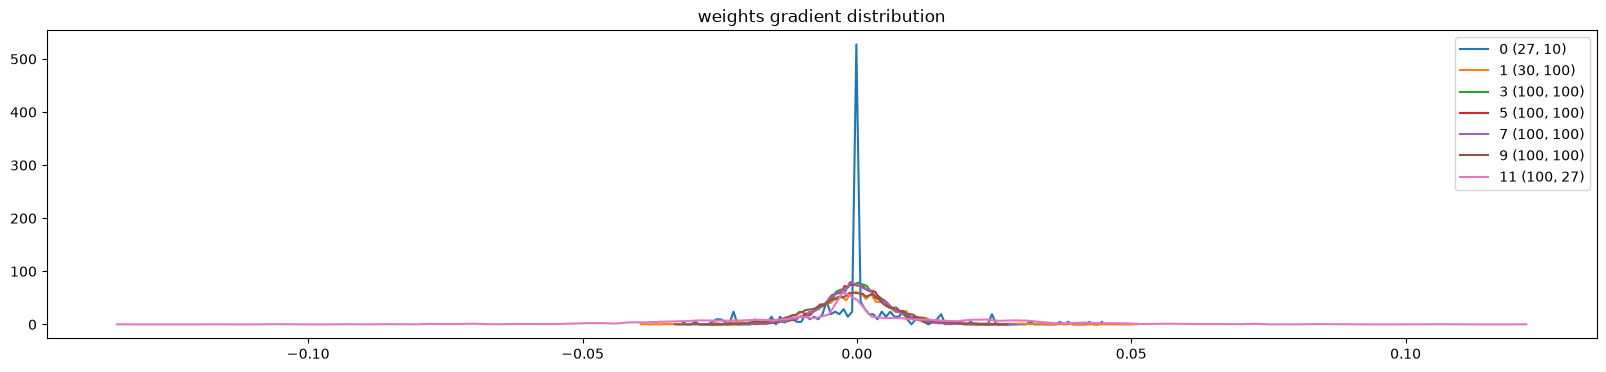

In [ ]:
# visualize histograms / looks only at weights
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

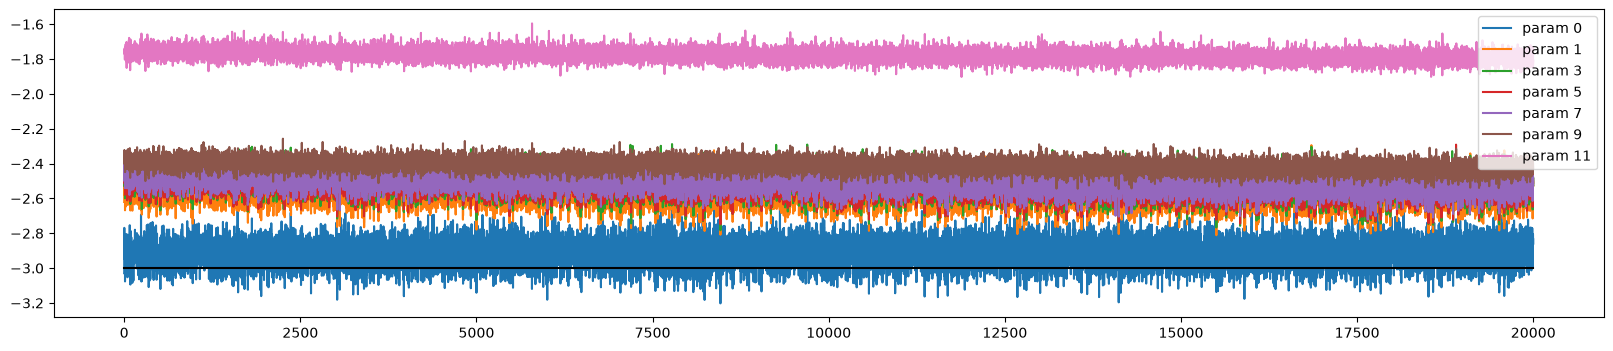

In [ ]:
# overtime data ratios, one to find -3 on the log scale for the ratio, if higher than learning rates too big/ vice-versa
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [19]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.112792491912842
val 2.175863027572632


In [20]:

# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carlah.
azuri.
vifrimley.
taty.
salan.
kenlehutvaeheryst.
taqri.
jermari.
chriivon.
leigh.
ham.
joce.
quintis.
lilan.
jadis.
wryella.
jarisi.
jaquelissan.
eddeli.
abetan.


Deep neural netwroks are very delicate, when changing parameters they can break even at small values

We created a function to handle the makemore calculationsin pytorch style, we have new variables to move around with graphs to visualize how they are acting, note they are very delicate

all of the implementation we made works with pytorch, just add n..___ the classes we made, classes there just to understand the physical components

for looking how a neural network does we introduced graphs

look at histogram, statistics, and activation of the forward/backward/weights

tools are not fully understood, later video will go indepth on how they truly work for now they are just a benchmark